In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import pickle
from scipy.stats import norm
from scipy import stats
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [2]:
def to_day(di):
    if di >= 2:
        return "day6"
    else:
        return "day" + str(di + 1)

In [3]:
with open("beh.pkl", "rb") as f:
    beh = pickle.load(f)
with open("h_spike.pkl", "rb") as f:
    h = pickle.load(f)

In [4]:
width = 50
save_50 = []
for mi in range(6):
    save_s = []
    for di in range(3):
        t_h, k = h[mi][di].shape
        t = t_h - 49
        mean = h[mi][di].mean(axis=0)
        std = h[mi][di].std(axis=0)
        succ = np.where(beh[mi][di][:, 2] == 1)[0]
        miss = np.where((beh[mi][di][:, 2] == 0) & (beh[mi][di][:, 1] == 1))[0]
        succ = succ[(succ + 49 >= width) & (succ + width < t)]
        miss = miss[(miss + 49 >= width) & (miss + width < t)]
        n_succ = len(succ)
        n_miss = len(miss)
        tmp = np.zeros((2*width+1, k, 2))
        for i in range(1,width+1):
            tmp[width-i, :, 0] = (h[mi][di][succ+49-i].mean(axis=0) - mean) / std
            tmp[width+i, :, 0] = (h[mi][di][succ+49+i].mean(axis=0) - mean) / std
            tmp[width-i, :, 1] = (h[mi][di][miss+49-i].mean(axis=0) - mean) / std
            tmp[width+i, :, 1] = (h[mi][di][miss+49+i].mean(axis=0) - mean) / std
        tmp[width, :, 0] = (h[mi][di][succ+49].mean(axis=0) - mean) / std
        tmp[width, :, 1] = (h[mi][di][miss+49].mean(axis=0) - mean) / std
        save_s.append(tmp)
    save_50.append(save_s)

In [5]:
width = 100
save_100 = []
for mi in range(6):
    save_s = []
    for di in range(3):
        t_h, k = h[mi][di].shape
        t = t_h - 49
        mean = h[mi][di].mean(axis=0)
        std = h[mi][di].std(axis=0)
        succ = np.where(beh[mi][di][:, 2] == 1)[0]
        miss = np.where((beh[mi][di][:, 2] == 0) & (beh[mi][di][:, 1] == 1))[0]
        succ = succ[(succ + 49 >= width) & (succ + width < t)]
        miss = miss[(miss + 49 >= width) & (miss + width < t)]
        n_succ = len(succ)
        n_miss = len(miss)
        tmp = np.zeros((2*width+1, k, 2))
        for i in range(1,width+1):
            tmp[width-i, :, 0] = (h[mi][di][succ+49-i].mean(axis=0) - mean) / std
            tmp[width+i, :, 0] = (h[mi][di][succ+49+i].mean(axis=0) - mean) / std
            tmp[width-i, :, 1] = (h[mi][di][miss+49-i].mean(axis=0) - mean) / std
            tmp[width+i, :, 1] = (h[mi][di][miss+49+i].mean(axis=0) - mean) / std
        tmp[width, :, 0] = (h[mi][di][succ+49].mean(axis=0) - mean) / std
        tmp[width, :, 1] = (h[mi][di][miss+49].mean(axis=0) - mean) / std
        save_s.append(tmp)
    save_100.append(save_s)

In [6]:
width = 50
corr_50 = []
for mi in range(6):
    corr_s = []
    for di in range(3):
        k = save_50[mi][di].shape[1]
        tmp = np.zeros((k, 2))
        for ki in range(k):
            tmp[ki, 0] = np.corrcoef(save_50[mi][di][:width, ki, :].T)[1, 0]
            tmp[ki, 1] = np.corrcoef(save_50[mi][di][-width:, ki, :].T)[1, 0]
        corr_s.append(tmp)
    corr_50.append(corr_s)

In [7]:
width = 100
corr_100 = []
for mi in range(6):
    corr_s = []
    for di in range(3):
        k = save_100[mi][di].shape[1]
        tmp = np.zeros((k, 2))
        for ki in range(k):
            tmp[ki, 0] = np.corrcoef(save_100[mi][di][:width, ki, :].T)[1, 0]
            tmp[ki, 1] = np.corrcoef(save_100[mi][di][-width:, ki, :].T)[1, 0]
        corr_s.append(tmp)
    corr_100.append(corr_s)

mouse1 day1


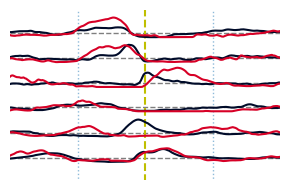

mouse1 day2


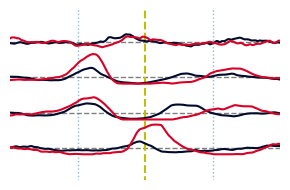

mouse1 day6


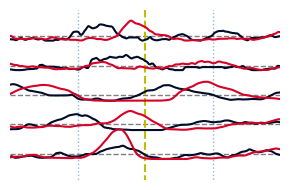

mouse2 day1


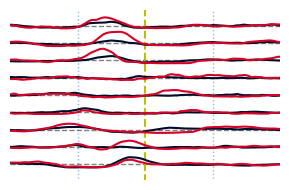

mouse2 day2


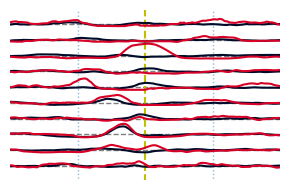

mouse2 day6


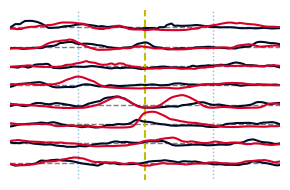

mouse3 day1


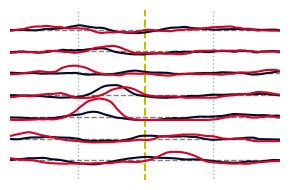

mouse3 day2


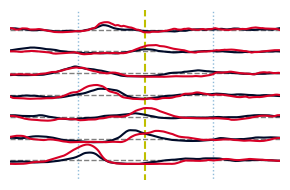

mouse3 day6


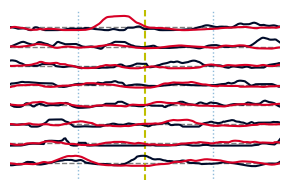

mouse4 day1


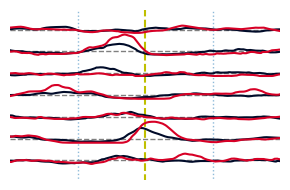

mouse4 day2


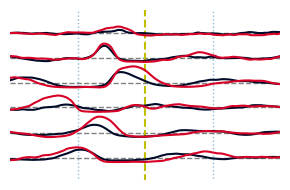

mouse4 day6


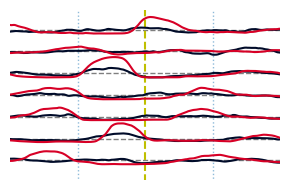

mouse5 day1


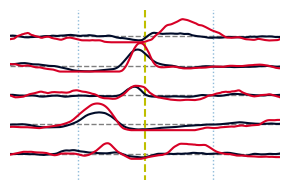

mouse5 day2


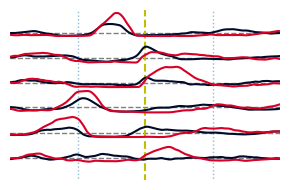

mouse5 day6


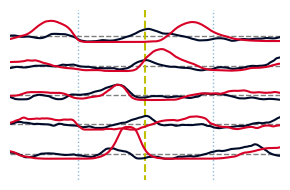

mouse6 day1


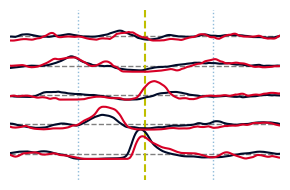

mouse6 day2


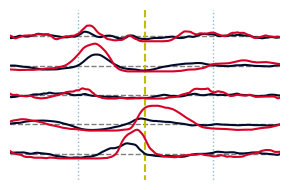

mouse6 day6


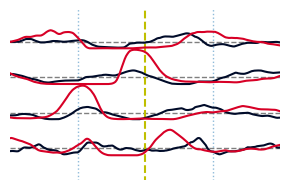

In [8]:
scale = 3
for mi in range(6):
    mouse = "mouse" + str(mi + 1)
    for di in range(3):
        day = to_day(di)
        print(mouse, day)
        tmp = save_100[mi][di].copy()
        tmp[tmp > 5] = 5
        tmp[tmp < -5] = -5
        k = tmp.shape[1]
        plt.figure(figsize=(3, 2))
        for i in range(k):
            for j, color in enumerate(["#d70026", "#000b29"]):
                plt.plot(tmp[:, i, j] - scale*i, c=color, zorder=2-j)
            plt.hlines(-scale*i, 0, 200, color="k", alpha=0.5, zorder=0, linestyles="--", linewidth=1)
        plt.xlim(0, 200)
        plt.yticks([-scale*i for i in range(k)])
        plt.ylim(-scale*(k-0.1), scale * 0.9)
        plt.vlines(100, -scale*k, scale, color="y", linestyles="--", zorder=0)
        plt.vlines(50, -scale*k, scale, color="C0", alpha=0.5, linestyles=":", linewidth=1, zorder=0)
        plt.vlines(150, -scale*k, scale, color="C0", alpha=0.5, linestyles=":", linewidth=1, zorder=0)
        plt.tick_params(labelleft=False, labelbottom=False)
        plt.axis("off")
        plt.tight_layout()
        plt.savefig("figures/fig5/fig5b_{}_{}.png".format(mouse, day))
        plt.show()

In [9]:
corr_day_50 = [np.vstack([corr_50[mi][di] for mi in range(6)]) for di in range(3)]
corr_day_50_pre = [corr_day_50[di][:, 0] for di in range(3)]
corr_day_50_post = [corr_day_50[di][:, 1] for di in range(3)]
corr_day_100 = [np.vstack([corr_100[mi][di] for mi in range(6)]) for di in range(3)]
corr_day_100_pre = [corr_day_100[di][:, 0] for di in range(3)]
corr_day_100_post = [corr_day_100[di][:, 1] for di in range(3)]

F_onewayResult(statistic=8.190584122707872, pvalue=0.0004809336791234868)
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  Day1   Day2    0.021  0.976 -0.2167  0.2587  False
  Day1   Day6  -0.3446 0.0025 -0.5839 -0.1052   True
  Day2   Day6  -0.3656 0.0013 -0.6065 -0.1247   True
----------------------------------------------------


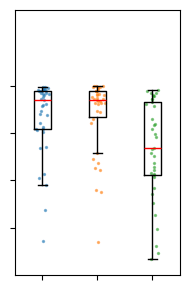

In [10]:
plt.figure(figsize=(2, 3))
plt.boxplot(corr_day_50_pre, sym="", medianprops={"color": "r"})
plt.tick_params(labelleft=False, labelbottom=False)
plt.ylim(-1, 1.8)
plt.yticks([-0.5, 0, 0.5, 1.0])
for i in range(3):
    plt.scatter(np.random.normal(0, 0.05, size=len(corr_day_50_pre[i]))+i+1, corr_day_50_pre[i], s=2, alpha=0.5)
plt.tight_layout()
plt.savefig("figures/fig5/fig5f.png")
print(stats.f_oneway(corr_day_50_pre[0], corr_day_50_pre[1], corr_day_50_pre[2]))
df = pd.DataFrame({
    "corrcoef": np.hstack(corr_day_50_pre),
    "day": np.hstack((
        ["Day1" for _ in corr_day_50[0]], 
        ["Day2" for _ in corr_day_50[1]], 
        ["Day6" for _ in corr_day_50[2]]))
})
tukey = pairwise_tukeyhsd(endog=df['corrcoef'],
                          groups=df['day'],
                          alpha=0.05)
print(tukey)

F_onewayResult(statistic=1.2851280044260474, pvalue=0.28069828427034965)
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Day1   Day2    0.009 0.9972 -0.2885 0.3065  False
  Day1   Day6  -0.1716  0.365 -0.4711  0.128  False
  Day2   Day6  -0.1806 0.3326  -0.482 0.1209  False
---------------------------------------------------


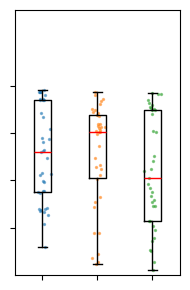

In [11]:
plt.figure(figsize=(2, 3))
plt.boxplot(corr_day_50_post, sym="", medianprops={"color": "r"})
plt.tick_params(labelleft=False, labelbottom=False)
plt.ylim(-1, 1.8)
plt.yticks([-0.5, 0, 0.5, 1.0])
for i in range(3):
    plt.scatter(np.random.normal(0, 0.05, size=len(corr_day_50_post[i]))+i+1, corr_day_50_post[i], s=2, alpha=0.5)
plt.tight_layout()
plt.savefig("figures/fig5/fig5g.png")
print(stats.f_oneway(corr_day_50_post[0], corr_day_50_post[1], corr_day_50_post[2]))
df = pd.DataFrame({
    "corrcoef": np.hstack(corr_day_50_post),
    "day": np.hstack((
        ["Day1" for _ in corr_day_50[0]], 
        ["Day2" for _ in corr_day_50[1]], 
        ["Day6" for _ in corr_day_50[2]]))
})
tukey = pairwise_tukeyhsd(endog=df['corrcoef'],
                          groups=df['day'],
                          alpha=0.05)
print(tukey)

F_onewayResult(statistic=6.607051247987704, pvalue=0.0019450915830473618)
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  Day1   Day2   0.0557 0.8024 -0.1534  0.2647  False
  Day1   Day6   -0.249  0.016 -0.4594 -0.0385   True
  Day2   Day6  -0.3047 0.0025 -0.5165 -0.0928   True
----------------------------------------------------


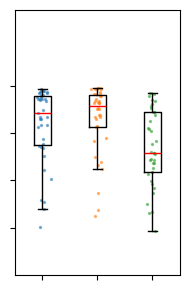

In [12]:
plt.figure(figsize=(2, 3))
plt.boxplot(corr_day_100_pre, sym="", medianprops={"color": "r"})
plt.tick_params(labelleft=False, labelbottom=False)
plt.ylim(-1, 1.8)
plt.yticks([-0.5, 0, 0.5, 1.0])
for i in range(3):
    plt.scatter(np.random.normal(0, 0.05, size=len(corr_day_100_pre[i]))+i+1, corr_day_100_pre[i], s=2, alpha=0.5)
plt.tight_layout()
plt.savefig("figures/fig5/fig5d.png")
print(stats.f_oneway(corr_day_100_pre[0], corr_day_100_pre[1], corr_day_100_pre[2]))
df = pd.DataFrame({
    "corrcoef": np.hstack(corr_day_100_pre),
    "day": np.hstack((
        ["Day1" for _ in corr_day_100[0]], 
        ["Day2" for _ in corr_day_100[1]], 
        ["Day6" for _ in corr_day_100[2]]))
})
tukey = pairwise_tukeyhsd(endog=df['corrcoef'],
                          groups=df['day'],
                          alpha=0.05)
print(tukey)

F_onewayResult(statistic=6.129386523536454, pvalue=0.0029856244911515397)
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Day1   Day2  -0.2298  0.064 -0.4702 0.0105  False
  Day1   Day6    -0.35 0.0024 -0.5919 -0.108   True
  Day2   Day6  -0.1201 0.4726 -0.3636 0.1234  False
---------------------------------------------------


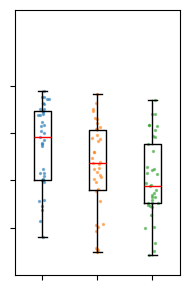

In [13]:
plt.figure(figsize=(2, 3))
plt.boxplot(corr_day_100_post, sym="", medianprops={"color": "r"})
plt.tick_params(labelleft=False, labelbottom=False)
plt.ylim(-1, 1.8)
plt.yticks([-0.5, 0, 0.5, 1.0])
for i in range(3):
    plt.scatter(np.random.normal(0, 0.05, size=len(corr_day_100_post[i]))+i+1, corr_day_100_post[i], s=2, alpha=0.5)
plt.tight_layout()
plt.savefig("figures/fig5/fig5e.png")
print(stats.f_oneway(corr_day_100_post[0], corr_day_100_post[1], corr_day_100_post[2]))
df = pd.DataFrame({
    "corrcoef": np.hstack(corr_day_100_post),
    "day": np.hstack((
        ["Day1" for _ in corr_day_100[0]], 
        ["Day2" for _ in corr_day_100[1]], 
        ["Day6" for _ in corr_day_100[2]]))
})
tukey = pairwise_tukeyhsd(endog=df['corrcoef'],
                          groups=df['day'],
                          alpha=0.05)
print(tukey)

day1
TtestResult(statistic=3.219776653254529, pvalue=0.002627837664106839, df=38)


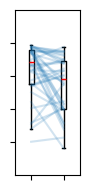

day2
TtestResult(statistic=7.431537165914658, pvalue=7.600990575676805e-09, df=37)


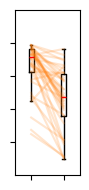

day6
TtestResult(statistic=3.9475982206758835, pvalue=0.0003512054565823179, df=36)


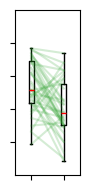

In [14]:
for di in range(3):
    day = to_day(di)
    plt.figure(figsize=(1, 2))
    plt.tick_params(labelleft=False, labelbottom=False)
    plt.ylim(-1, 1.5)
    plt.yticks([-0.5, 0, 0.5, 1.0])
    plt.boxplot(corr_day_100[di], sym="", medianprops={"color": "r"})
    plt.plot(np.array([[1,2] for _ in corr_day_100[di]]).T, corr_day_100[di].T, c="C"+str(di), alpha=0.2)
    plt.tight_layout()
    plt.savefig("figures/fig5/fig5c_{}.png".format(day))
    print(to_day(di))
    print(stats.ttest_rel(corr_day_100[di][:, 0], corr_day_100[di][:, 1]))
    plt.show()

In [15]:
width = 100
mi = 5
di = 2
t_h, k = h[mi][di].shape
t = t_h - 49
succ = np.where(beh[mi][di][:, 2] == 1)[0]
succ = succ[(succ + 49 >= width) & (succ + width < t)]
n_succ = len(succ)
n_miss = len(miss)
tmp = np.zeros((2*width+1, k))
for i in range(1,width+1):
    tmp[width-i, :] = h[mi][di][succ+49-i].mean(axis=0)
    tmp[width+i, :] = h[mi][di][succ+49+i].mean(axis=0)
tmp[width, :] = h[mi][di][succ+49].mean(axis=0)

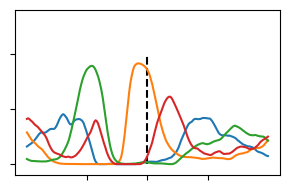

In [16]:
plt.figure(figsize=(3, 2))
plt.plot(tmp, zorder=1)
plt.vlines(x=width, ymin=0, ymax=1, color="k", linestyle="--", zorder=0)
plt.xticks([width-50, width, width+50])
plt.yticks([0, 0.5, 1.0])
plt.ylim(-0.1, 1.4)
plt.tick_params(labelleft=False, labelbottom=False)
plt.tight_layout()
plt.savefig("figures/figs7/figs7b.png")